In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split, GridSearchCV
from skimage.filters import gaussian
from skimage.util import img_as_ubyte
from pyfeats import glrlm_features
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

# Load Data

In [2]:
def load_data(data_dir):
    class_data = {}
    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)
        if os.path.isdir(class_path):
            images = []
            labels = []
            for img_name in os.listdir(class_path):
                img_path = os.path.join(class_path, img_name)
                img = cv2.imread(img_path)
                if img is not None:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    image = cv2.resize(img, (224, 224))
                    images.append(image)
                    labels.append(class_name)
            class_data[class_name] = (np.array(images), np.array(labels))
    return class_data

data_dir = "../data_full_mpox_only/"
data_by_class = load_data(data_dir)

# Akses data tiap folder
class1_images, class1_labels = data_by_class['Monkeypox']
class2_images, class2_labels = data_by_class['Normal']

print(f'Total gambar Monkeypox: {len(class1_images)}')
print(f'Total gambar Normal: {len(class2_images)}')

Total gambar Monkeypox: 250
Total gambar Normal: 250


In [3]:
def split_data(class_data, test_size=0.2):
    train_images, train_labels = [], []
    test_images, test_labels = [], []

    for class_name, (images, labels) in class_data.items():
        X_train, X_test, y_train, y_test = train_test_split(
            images, labels, test_size=test_size, random_state=42, stratify=labels
        )

        train_images.extend(X_train)
        train_labels.extend(y_train)
        test_images.extend(X_test)
        test_labels.extend(y_test)

    return (
        (np.array(train_images), np.array(train_labels)),
        (np.array(test_images), np.array(test_labels))
    )

(train_data, test_data) = split_data(data_by_class)

X_train, y_train = train_data
X_test, y_test = test_data

print(f"Dimensi data train: {X_train.shape}")
print(f"Dimensi data test: {X_test.shape}")

Dimensi data train: (400, 224, 224, 3)
Dimensi data test: (100, 224, 224, 3)


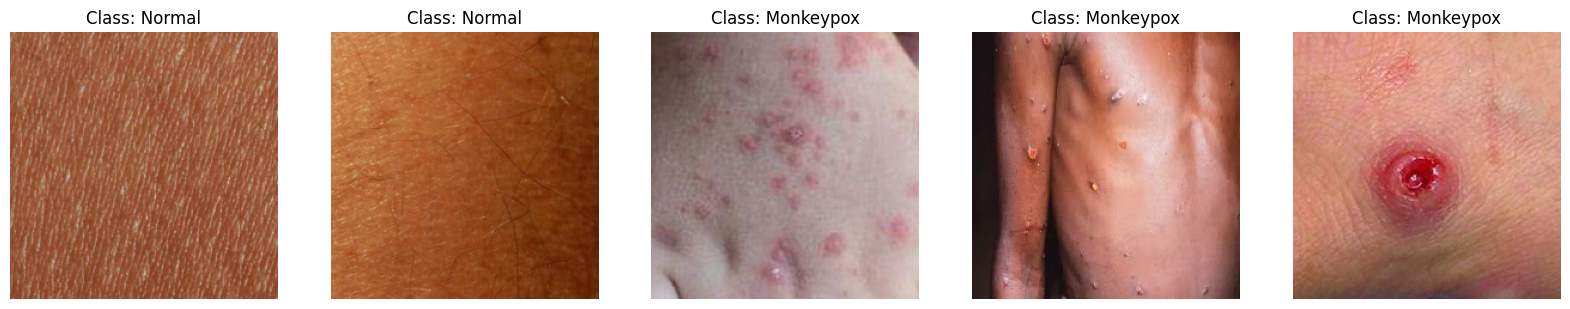

In [10]:
def show_images(images, labels):
    plt.figure(figsize=(20, 10))
    for i in range(5):
        idx = random.randint(0, len(images) - 1)
        plt.subplot(1, 5, i + 1)
        plt.imshow(images[idx].astype('uint8'))
        plt.title(f"Class: {labels[idx]}")
        plt.axis('off')
    plt.show()

show_images(X_train, y_train)

# Preprocessing Data

In [11]:
def preprocess_grayscale(image):
    gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    return gray_image

def preprocess_gaussian(image, sigma=1):
    blurred = gaussian(image, sigma=sigma)
    return img_as_ubyte(blurred)

In [12]:
def preprocess_all(images):
    preprocess_all_images = []
    
    for img in images:
        grayscale_image = preprocess_grayscale(img)
        blurred_image = preprocess_gaussian(grayscale_image)

        preprocess_all_images.append(blurred_image)
    
    return np.array(preprocess_all_images)

X_train_processed = preprocess_all(X_train)
X_test_processed = preprocess_all(X_test)

print(f"Dimensi data training setelah preprocessing: {X_train_processed.shape}")
print(f"Dimensi data testing setelah preprocessing: {X_test_processed.shape}")

Dimensi data training setelah preprocessing: (400, 224, 224)
Dimensi data testing setelah preprocessing: (100, 224, 224)


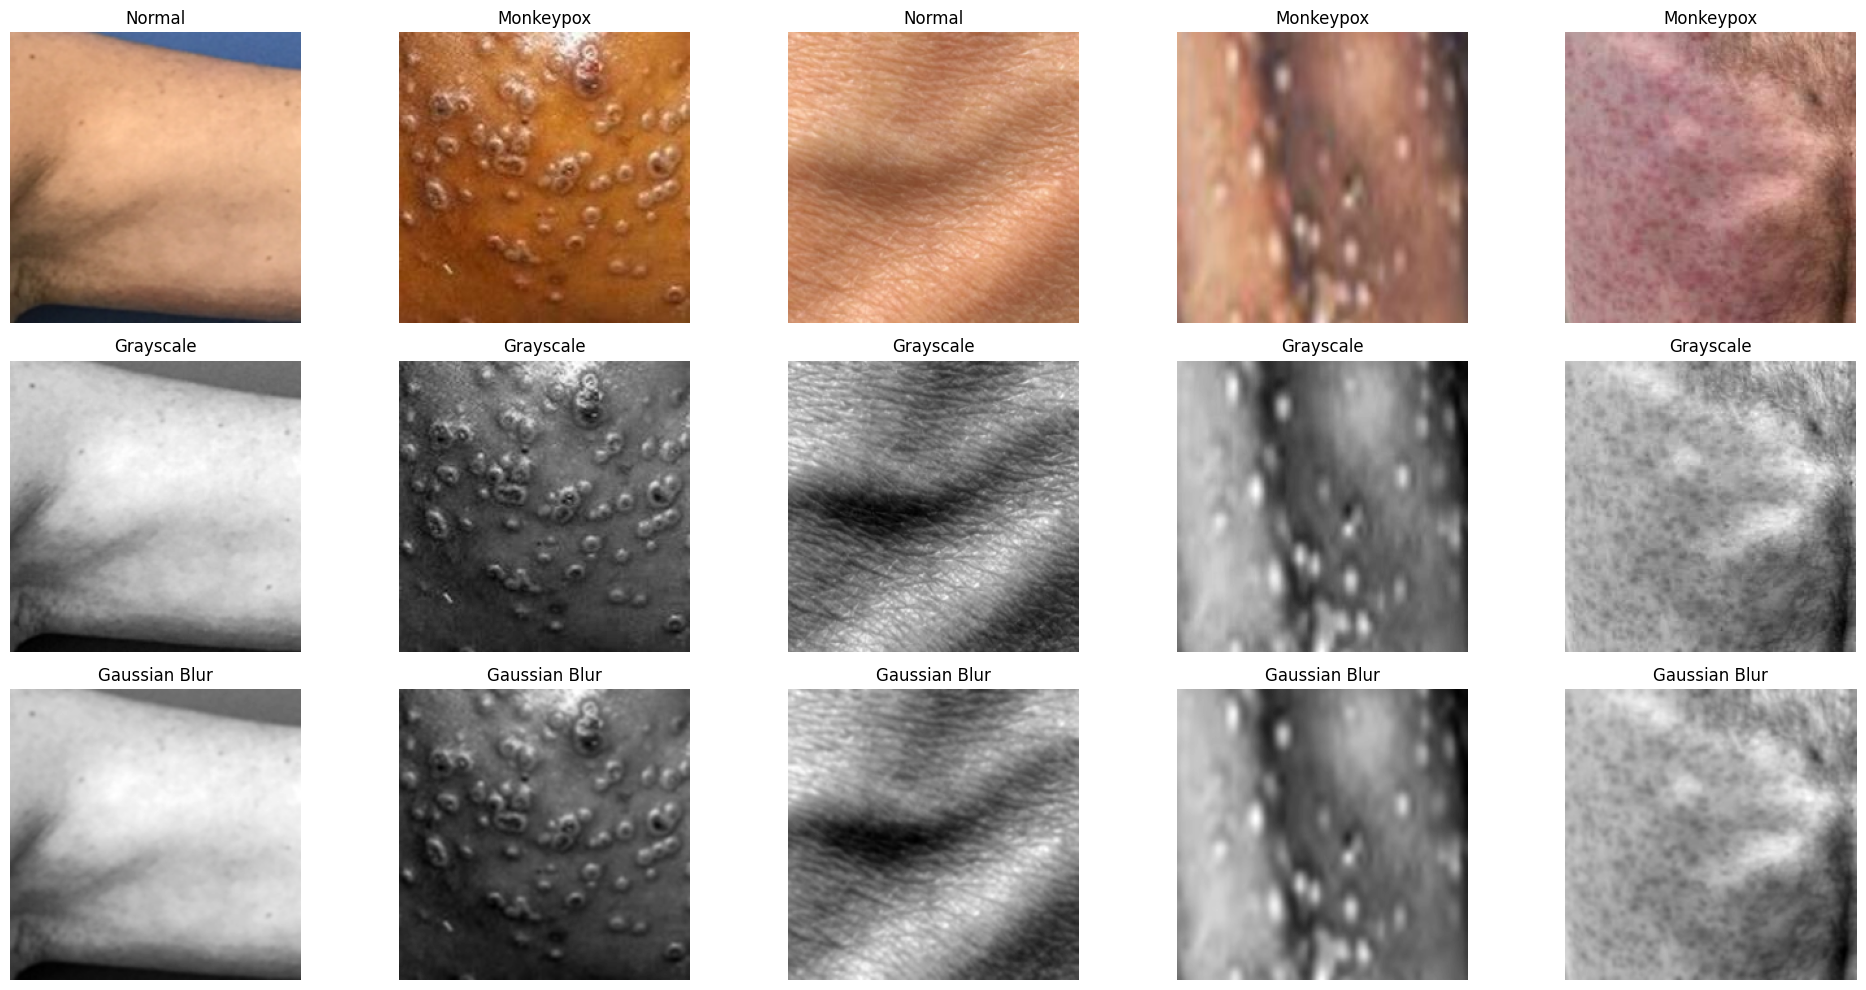

In [13]:
def display_preprocessing(images, labels, num_samples=5, seed=31):
    random.seed(seed) 
    indices = random.sample(range(len(X_train)), num_samples)  # Ambil indeks acak
    fig, axes = plt.subplots(3, num_samples, figsize=(20, 10))

    for i, idx in enumerate(indices):
        original_image = images[idx]
        processed_grayscale = preprocess_grayscale(original_image)
        processed_gaussian = preprocess_gaussian(processed_grayscale)

        # Plot hasil setiap langkah
        axes[0, i].imshow(original_image)
        axes[0, i].set_title(labels[idx])
        axes[0, i].axis('off')
        
        axes[1, i].imshow(processed_grayscale, cmap='gray')
        axes[1, i].set_title("Grayscale")
        axes[1, i].axis('off')
        
        axes[2, i].imshow(processed_gaussian, cmap='gray')
        axes[2, i].set_title("Gaussian Blur")
        axes[2, i].axis('off')
        
    plt.tight_layout()
    plt.show()

# Menampilkan hasil untuk 5 gambar dari data training
display_preprocessing(X_train, y_train, num_samples=5)

# Feature Extraction

In [14]:
def extract_glrlm_features(images):
    selected_features = [
        "GLRLM_ShortRunEmphasis",
        "GLRLM_LongRunEmphasis",
        "GLRLM_GrayLevelNo-Uniformity",
        "GLRLM_RunLengthNonUniformity",
        "GLRLM_RunPercentage",
    ]
    features_list = []
    
    for img in images:
        mask = np.ones_like(img, dtype=np.uint8)
        features, labels = glrlm_features(img, mask)
        
        selected_features_indices = [labels.index(f) for f in selected_features]
        filtered_features = features[selected_features_indices]
        features_list.append(filtered_features)
    
    return np.array(features_list)

X_train_features = extract_glrlm_features(X_train_processed)
X_test_features = extract_glrlm_features(X_test_processed)

print(f"Dimensi data training setelah ekstraksi fitur: {X_train_features.shape}")
print(f"Dimensi data testing setelah ekstraksi fitur: {X_test_features.shape}")

Dimensi data training setelah ekstraksi fitur: (400, 5)
Dimensi data testing setelah ekstraksi fitur: (100, 5)


# Classification

#### RBF Kernel

In [15]:
rbf_params = {
    'C': [0.01, 0.1, 1, 10, 100, 1000],
    'gamma': [0.01, 0.1, 1, 10, 100, 1000, 'scale'],
    'kernel': ['rbf']
}

svm_rbf = GridSearchCV(estimator=SVC(), param_grid=rbf_params, cv=5, verbose=3)
svm_rbf.fit(X_train_features, y_train)

# Menampilkan hasil parameter terbaik
print("\nBest Parameters:", svm_rbf.best_params_)
print("Best Score:", svm_rbf.best_score_)

Fitting 5 folds for each of 42 candidates, totalling 210 fits
[CV 1/5] END ....C=0.01, gamma=0.01, kernel=rbf;, score=0.512 total time=   0.0s
[CV 2/5] END ....C=0.01, gamma=0.01, kernel=rbf;, score=0.537 total time=   0.0s
[CV 3/5] END ....C=0.01, gamma=0.01, kernel=rbf;, score=0.512 total time=   0.0s
[CV 4/5] END ....C=0.01, gamma=0.01, kernel=rbf;, score=0.500 total time=   0.0s
[CV 5/5] END ....C=0.01, gamma=0.01, kernel=rbf;, score=0.575 total time=   0.0s
[CV 1/5] END .....C=0.01, gamma=0.1, kernel=rbf;, score=0.512 total time=   0.0s
[CV 2/5] END .....C=0.01, gamma=0.1, kernel=rbf;, score=0.525 total time=   0.0s
[CV 3/5] END .....C=0.01, gamma=0.1, kernel=rbf;, score=0.512 total time=   0.0s
[CV 4/5] END .....C=0.01, gamma=0.1, kernel=rbf;, score=0.500 total time=   0.0s
[CV 5/5] END .....C=0.01, gamma=0.1, kernel=rbf;, score=0.562 total time=   0.0s
[CV 1/5] END .......C=0.01, gamma=1, kernel=rbf;, score=0.512 total time=   0.0s
[CV 2/5] END .......C=0.01, gamma=1, kernel=rbf

In [16]:
y_test_pred_rbf = svm_rbf.best_estimator_.predict(X_test_features)
test_accuracy_rbf = accuracy_score(y_test, y_test_pred_rbf) * 100
test_precision_rbf = precision_score(y_test, y_test_pred_rbf, average='macro') * 100
test_recall_rbf = recall_score(y_test, y_test_pred_rbf, average='macro') * 100
test_f1_rbf = f1_score(y_test, y_test_pred_rbf, average='macro') * 100

print("Kernel: RBF")
print(f"Accuracy: {test_accuracy_rbf:.2f}")

class_labels = np.unique(y_test)
for label in class_labels:
    class_indices = y_test == label
    class_predictions = y_test_pred_rbf[class_indices]
    correct_predictions = (class_predictions == label).sum()
    total_samples = class_indices.sum()
    class_accuracy = (correct_predictions / total_samples) * 100
    print(f"Accuracy for class {label}: {class_accuracy:.2f}")

print(f"\nOverall Precision: {test_precision_rbf:.2f}")
print(f"Overall Recall: {test_recall_rbf:.2f}")
print(f"Overall F1-score: {test_f1_rbf:.2f}")

print("\nClassification Report on Test Data:\n")
print(classification_report(y_test, y_test_pred_rbf))

Kernel: RBF
Accuracy: 84.00
Accuracy for class Monkeypox: 88.00
Accuracy for class Normal: 80.00

Overall Precision: 84.22
Overall Recall: 84.00
Overall F1-score: 83.97

Classification Report on Test Data:

              precision    recall  f1-score   support

   Monkeypox       0.81      0.88      0.85        50
      Normal       0.87      0.80      0.83        50

    accuracy                           0.84       100
   macro avg       0.84      0.84      0.84       100
weighted avg       0.84      0.84      0.84       100



#### Linear Kernel

In [17]:
svm_linear = SVC(kernel='linear', C=1.0)
svm_linear.fit(X_train_features, y_train)
y_test_pred_linear = svm_linear.predict(X_test_features)
test_accuracy_linear = accuracy_score(y_test, y_test_pred_linear) * 100
test_precision_linear = precision_score(y_test, y_test_pred_linear, average='macro') * 100
test_recall_linear = recall_score(y_test, y_test_pred_linear, average='macro') * 100
test_f1_linear = f1_score(y_test, y_test_pred_linear, average='macro') * 100

print("Kernel: Linear")
print(f"Accuracy: {test_accuracy_linear:.2f}")

class_labels = np.unique(y_test)
for label in class_labels:
    class_indices = y_test == label
    class_predictions = y_test_pred_linear[class_indices]
    correct_predictions = (class_predictions == label).sum()
    total_samples = class_indices.sum()
    class_accuracy = (correct_predictions / total_samples) * 100
    print(f"Accuracy for class {label}: {class_accuracy:.2f}")

print(f"\nOverall Precision: {test_precision_linear:.2f}")
print(f"Overall Recall: {test_recall_linear:.2f}")
print(f"Overall F1-score: {test_f1_linear:.2f}")

print("\nClassification Report on Test Data:\n")
print(classification_report(y_test, y_test_pred_linear))

Kernel: Linear
Accuracy: 79.00
Accuracy for class Monkeypox: 92.00
Accuracy for class Normal: 66.00

Overall Precision: 81.10
Overall Recall: 79.00
Overall F1-score: 78.64

Classification Report on Test Data:

              precision    recall  f1-score   support

   Monkeypox       0.73      0.92      0.81        50
      Normal       0.89      0.66      0.76        50

    accuracy                           0.79       100
   macro avg       0.81      0.79      0.79       100
weighted avg       0.81      0.79      0.79       100



#### Polynomial Kernel

In [18]:
svm_poly = SVC(kernel='poly', C=1000, gamma='scale', degree=3)
svm_poly.fit(X_train_features, y_train)
y_test_pred_poly = svm_poly.predict(X_test_features)
test_accuracy_poly = accuracy_score(y_test, y_test_pred_poly) * 100
test_precision_poly = precision_score(y_test, y_test_pred_poly, average='macro') * 100
test_recall_poly = recall_score(y_test, y_test_pred_poly, average='macro') * 100
test_f1_poly = f1_score(y_test, y_test_pred_poly, average='macro') * 100

print("Kernel: Polynomial")
print(f"Accuracy: {test_accuracy_poly:.2f}")

class_labels = np.unique(y_test)
for label in class_labels:
    class_indices = y_test == label
    class_predictions = y_test_pred_poly[class_indices]
    correct_predictions = (class_predictions == label).sum()
    total_samples = class_indices.sum()
    class_accuracy = (correct_predictions / total_samples) * 100
    print(f"Accuracy for class {label}: {class_accuracy:.2f}")

print(f"\nOverall Precision: {test_precision_linear:.2f}")
print(f"Overall Recall: {test_recall_linear:.2f}")
print(f"Overall F1-score: {test_f1_linear:.2f}")

print("\nClassification Report on Test Data:\n")
print(classification_report(y_test, y_test_pred_poly))

Kernel: Polynomial
Accuracy: 83.00
Accuracy for class Monkeypox: 80.00
Accuracy for class Normal: 86.00

Overall Precision: 81.10
Overall Recall: 79.00
Overall F1-score: 78.64

Classification Report on Test Data:

              precision    recall  f1-score   support

   Monkeypox       0.85      0.80      0.82        50
      Normal       0.81      0.86      0.83        50

    accuracy                           0.83       100
   macro avg       0.83      0.83      0.83       100
weighted avg       0.83      0.83      0.83       100



In [19]:
def calculate_gamma_scale(X):
    n_features = X.shape[1]  # Jumlah fitur pada data
    data_variance = np.var(X, axis=0).mean()  # Rata-rata variansi setiap fitur
    gamma_scale = 1 / (n_features * data_variance)  # Menghitung gamma_scale
    
    return gamma_scale

gamma_scale = calculate_gamma_scale(X_train_features)
print(f"Nilai gamma (scale): {gamma_scale}")

Nilai gamma (scale): 1.054678902940462e-08


# Confusion Matrix

#### RBF Kernel

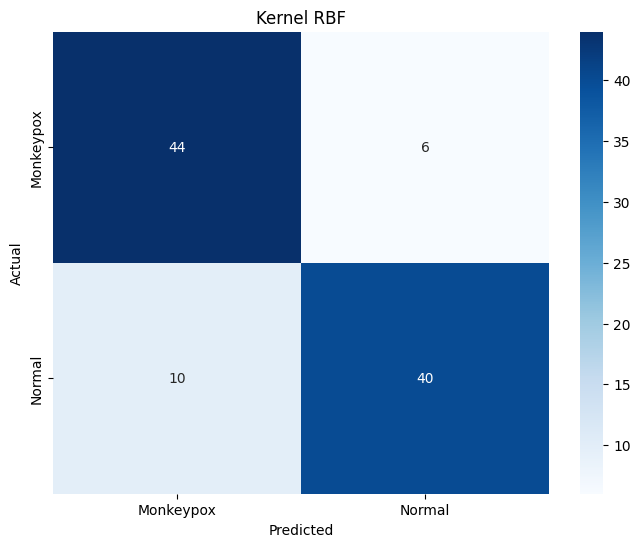

In [20]:
cm_rbf = confusion_matrix(y_test, y_test_pred_rbf)
classes = np.unique(y_test)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rbf, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.title("Kernel RBF")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### Linear Kernel

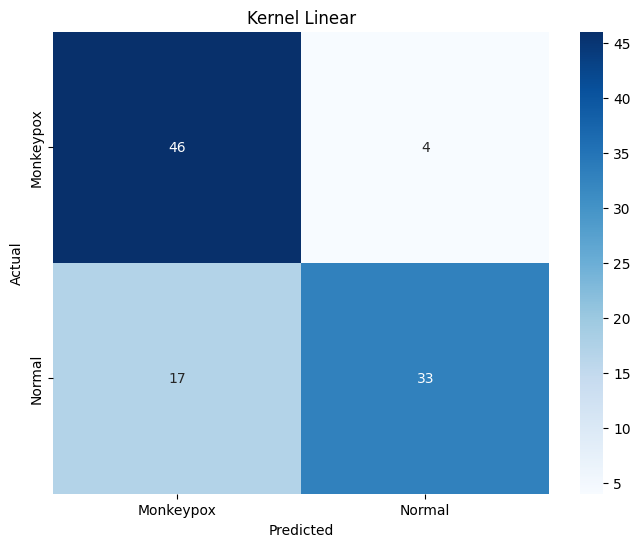

In [21]:
cm_linear = confusion_matrix(y_test, y_test_pred_linear)
classes = np.unique(y_test)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_linear, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.title("Kernel Linear")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### Polynomial Kernel

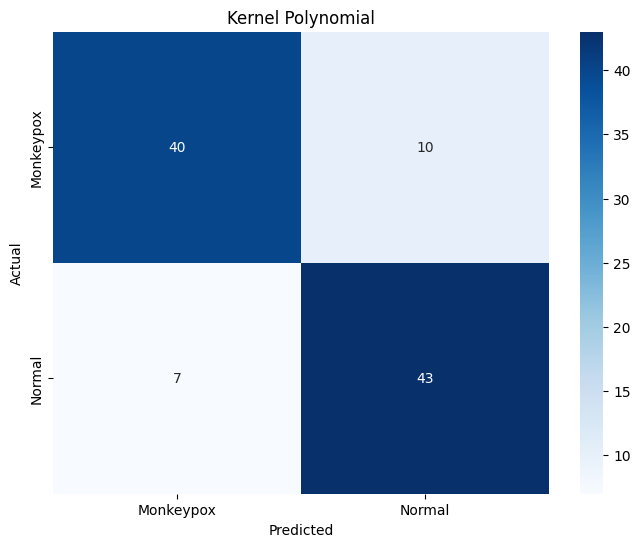

In [22]:
cm_poly = confusion_matrix(y_test, y_test_pred_poly)
classes = np.unique(y_test)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_poly, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.title("Kernel Polynomial")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Save Model

In [ ]:
with open("svm_model_rbf.pkl", "wb") as file:
    pickle.dump(svm_rbf, file)

In [ ]:
with open("svm_model_linear.pkl", "wb") as file:
    pickle.dump(svm_linear, file)

In [ ]:
with open("svm_model_poly.pkl", "wb") as file:
    pickle.dump(svm_poly, file)